# Лабораторная работа №3
### Выполнила студентка группы БВТ2101 Пьянова Анна

**Тема: Обнаружение объектов с использованием Faster R-CNN**

**Цель работы:** Ознакомиться с архитектурой Faster R-CNN и принципами двухэтапного обнаружения объектов.

**Задачи:**
- Изучить теоретические основы двухэтапного обнаружения объектов: роль RPN и классификационного этапа в Faster R-CNN.
- Загрузить предобученную модель Faster R-CNN.
- Ознакомиться с форматом аннотаций для обучения в задаче детекции.
- Визуализировать предсказания, проанализировать ошибки модели и провести исследование по поиску баланса FN/FP.

### 1. Теоретическая часть

В данной лабораторной работе мы познакомимся с задачей детекции на примере архитектуры [Faster R-CNN](https://arxiv.org/pdf/1506.01497), обученной на наборе данных [COCO](https://cocodataset.org/#home), а также с новым форматом данных для обучения нейро-сетевых моделей детекции. Для оценки модели воспользуемся набором данных [Pascal VOC 2007](http://host.robots.ox.ac.uk/pascal/VOC/).

**Перед тем, как приступать к выполнению практической части, ознакомьтесь с первоисточниками используемых компонентов, а также документацией по [ссылке](https://pytorch.org/vision/master/models/faster_rcnn.html), включающей подробности работы с моделью и новым форматом данных, сэмплы кода.**

#### 1.1 Архитектура Faster R-CNN

Существует два основных подхода к обнаружению объектов:
Двухстадийные модели – более точные, но медленные.
Одностадийные модели – быстрые, но менее точные.

Faster R-CNN — это двухэтапная модель детекции объектов. В отличие от ResNeXt, Faster R-CNN не просто классифицирует изображение, а находит на нём несколько объектов, предсказывает bounding boxes и присваивает метки классам. Она состоит из следующих компонентов:

1. Backbone (ResNet/VGG/MobileNet) – извлекает признаки из изображения.
2. Region Proposal Network (RPN) – предлагает области, где могут находиться объекты.
3. ROI Pooling + Fully Connected Layers – классифицирует объекты и уточняет bounding boxes.
4. Non-Maximum Suppression (NMS) – убирает дублирующиеся предсказания.


В предыдущих лабораторных работах мы познакомились с классификацией изображений, где модель предсказывает единственный класс для всего изображения. Однако во многих задачах компьютерного зрения классификация недостаточна. Например, когда на одном изображении присутствуют несколько объектов разных классов необходимо не только определить, что изображено, но и где это находится.

Faster R-CNN –  модель, которая также решает задачу обнаружения объектов, добавляя к классификации локализацию.

#### 1.2 Формат данных для задачи детекции

Faster R-CNN требует разметки изображений, помимо классов включающей в себя и координаты bounding box по оси x, y.
Ознакомьтесь с форматом набора данных Pascal VOC, скачайте аннотации набора данных и изучите структуру **.xml** файлов в папке Annotations по [ссылке](http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtestnoimgs_06-Nov-2007.tar).

#### 1.3 Оценка качества

Помимо известных вам инструментов оценить качество работы детектора могут помочь:

Confidence Score - значение, указывающее на уверенность модели в том, что на данном месте изображения находится объект. Модель предсказывает этот параметр для каждого предсказанного bounding box. Чем выше confidence score, тем более уверена модель в своём предсказании.

Фильтрация предсказаний - модель может предсказать много объектов, но не все из них будут точными. Чтобы уменьшить количество ложных срабатываний (False Positives), применяется фильтр предсказаний, используя confidence threshold. Если confidence score меньше заданного порога - предсказание отбрасывается.


### 2. Практическая часть

#### 2.1 Подготовка окружения

Установите зависимости и библиотеки:

In [1]:
import torch
import torchvision
from torchvision import transforms, datasets
import numpy as np
from PIL import Image, ImageDraw
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os

#### 2.2 Подготовка модели

Загрузите предобученную модель, определите устройство, переведите модель в режим инференса:

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Используемое устройство:", device)

Используемое устройство: cuda


In [3]:
# импорт модели
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.to(device)
model.eval()  # режим инференса

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:01<00:00, 166MB/s]


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

#### 2.3 Загрузка и предобработка изображений


Затем импортируйте датасет из соответствующих пакетов PyTorch и определите метод трансформации данных для подачи в модель. Он понадобится позже для преобразования изображений при прямом проходе через модель чтобы получить предсказания:

In [4]:
# метод трансформации
transform = transforms.Compose([
    transforms.ToTensor(),
])

# загрузка датасета Pascal VOC
voc_dataset = datasets.VOCDetection(
    root='./data',
    year='2007',
    image_set='val',
    download=True,
    transform=transform
)

# классы Pascal VOC
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat',
    'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person',
    'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]


100%|██████████| 460M/460M [00:24<00:00, 19.1MB/s]


#### 2.4 Объявление методов для работы с данными

Далее необходимо создать методы препроцессинга: метод чтения файла аннотации для возврата numpy-объекта содержащего bounding boxes, и метод отрисовки истиных и прогнозных bounding boxes на изображении для визуализации полученных результатов.

In [5]:
# парсинг XML аннотации VOC
def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []

    for obj in root.findall("object"):
        bbox = obj.find("bndbox")
        xmin, ymin, xmax, ymax = (int(bbox.find("xmin").text), int(bbox.find("ymin").text),
                                  int(bbox.find("xmax").text), int(bbox.find("ymax").text))
        boxes.append([xmin, ymin, xmax, ymax])
    return np.array(boxes)

# отрисовка bounding boxes на изображении
def draw_predictions(image, boxes, labels, scores, color="blue"):
    draw = ImageDraw.Draw(image)
    for box, label, score in zip(boxes, labels, scores):
        xmin, ymin, xmax, ymax = map(int, box)
        draw.rectangle([xmin, ymin, xmax, ymax], outline=color, width=2)
        draw.text((xmin, ymin), f"{label} ({score:.2f})", fill=color)
    return image

#### 2.5 Анализ False Positives / False Negatives

Для измерения того, насколько хорошо bounding box предсказан, применяется параметр IoU (Intersection over Union) между двумя bounding boxes. Чем он выше, тем точнее предсказание. Для его оценки опишем следующий метод, принимающий два np.array-объекта (прогнозные и истинные координаты):

In [6]:
def calculate_iou(pred_box, gt_box):
    x1, y1, x2, y2 = pred_box
    x1g, y1g, x2g, y2g = gt_box

    xi1 = max(x1, x1g)
    yi1 = max(y1, y1g)
    xi2 = min(x2, x2g)
    yi2 = min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area > 0 else 0

#### 2.6 Оценка модели и визуализация результатов

Выполните прямой проход нескольких изображений через модель. Для этого необходимо загрузить изображения и аннотации, применить преобразование изображений в тензор. Затем получите выходы модели:


Изображение ./data/VOCdevkit/VOC2007/JPEGImages/000760.jpg:
Найдено объектов: 13
Истинных объектов: 10
Средний IoU: 0.11
False Positive: 3, False Negative: 0


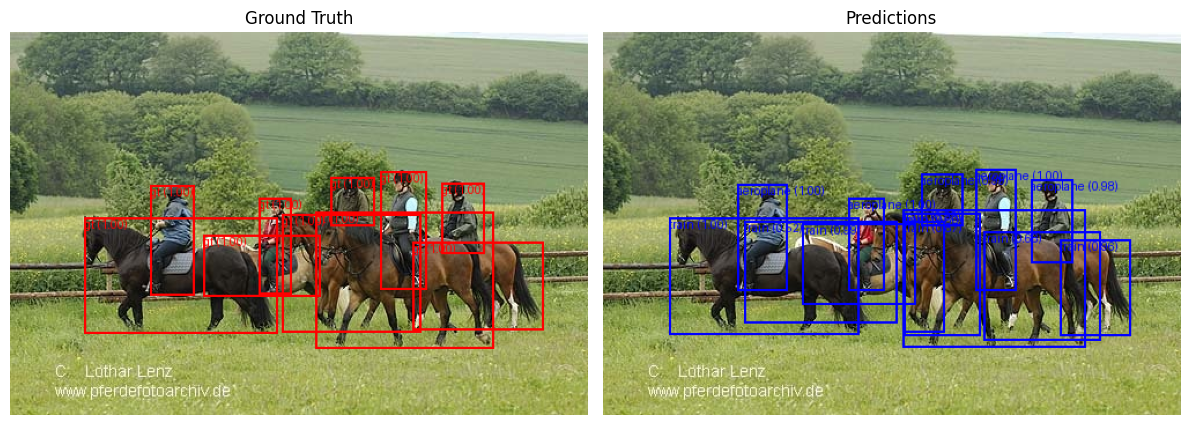


Изображение ./data/VOCdevkit/VOC2007/JPEGImages/004814.jpg:
Найдено объектов: 2
Истинных объектов: 1
Средний IoU: 0.73
False Positive: 1, False Negative: 0


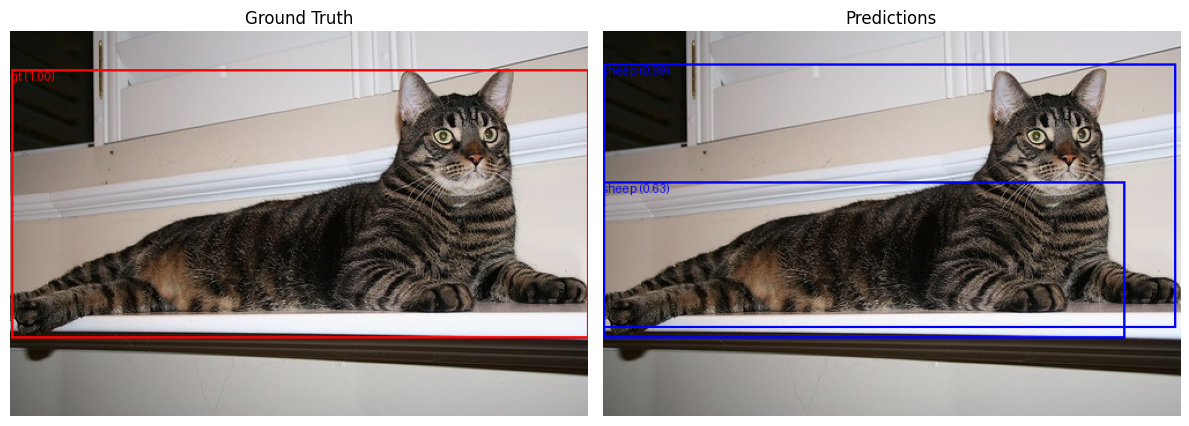


Изображение ./data/VOCdevkit/VOC2007/JPEGImages/008584.jpg:
Найдено объектов: 2
Истинных объектов: 1
Средний IoU: 0.22
False Positive: 1, False Negative: 0


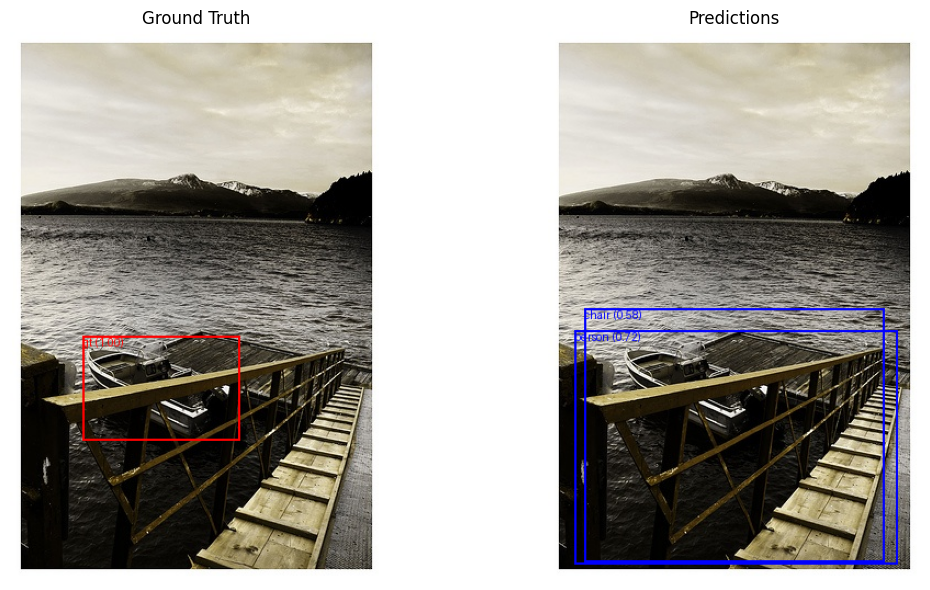


Изображение ./data/VOCdevkit/VOC2007/JPEGImages/001523.jpg:
Найдено объектов: 2
Истинных объектов: 2
Средний IoU: 0.64
False Positive: 0, False Negative: 0


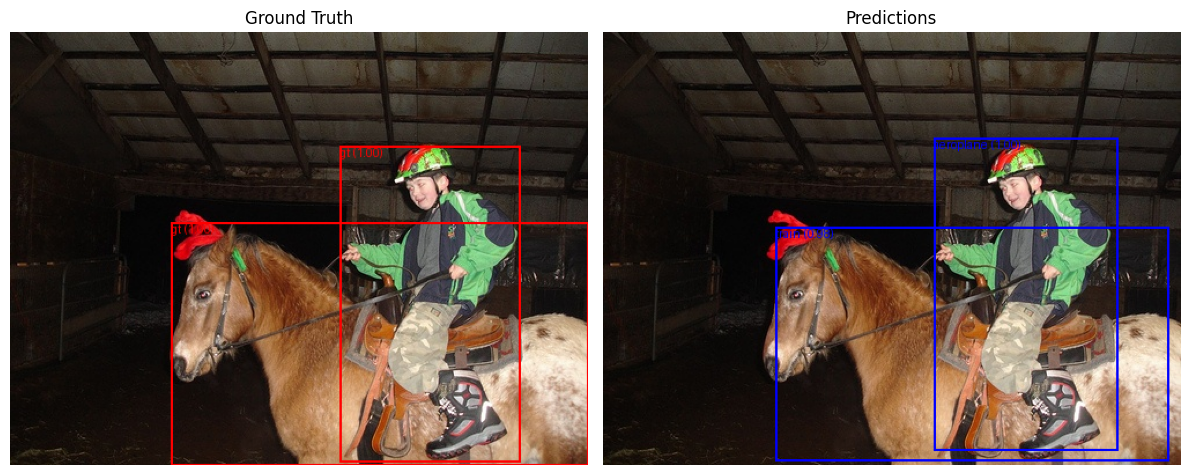


Изображение ./data/VOCdevkit/VOC2007/JPEGImages/003597.jpg:
Найдено объектов: 2
Истинных объектов: 1
Средний IoU: 0.61
False Positive: 1, False Negative: 0


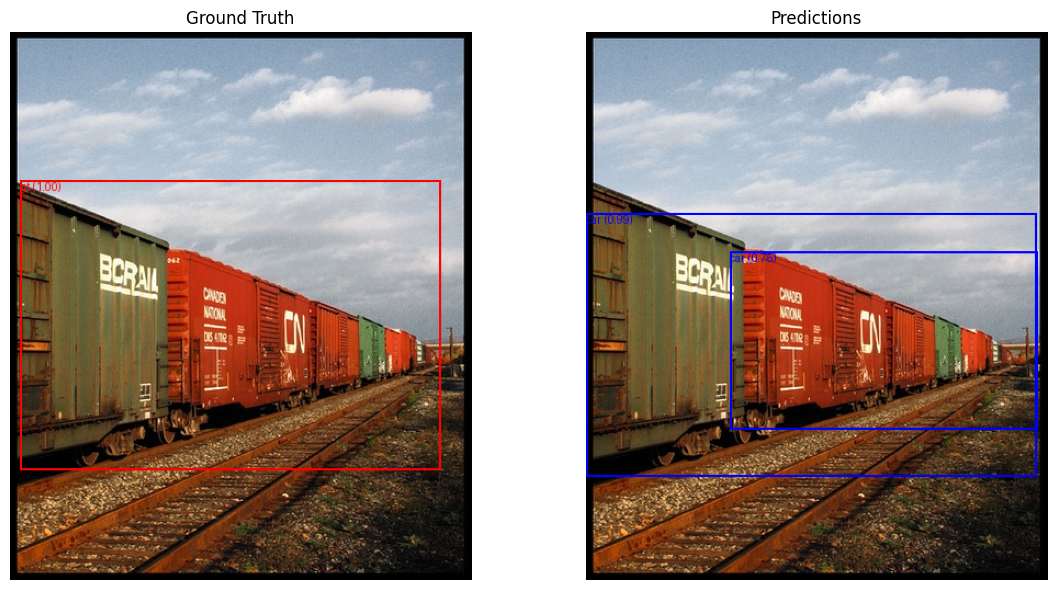

In [ ]:
# выбор N изображений из датасета
N = 5
image_indices = np.random.choice(len(voc_dataset), N, replace=False)

for idx, i in enumerate(image_indices):
    # загрузка данных
    image, target = voc_dataset[i]
    image_id = target['annotation']['filename'].split('.')[0]
    image_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', f"{image_id}.jpg")
    xml_path = os.path.join('./data/VOCdevkit/VOC2007/Annotations', f"{image_id}.xml")

    if not os.path.exists(image_path):
        print(f"Изображение {image_path} не найдено, пропускаем")
        continue

    if not os.path.exists(xml_path):
        print(f"Аннотация {xml_path} не найдена, пропускаем")
        continue

    # парсинг аннотации
    gt_boxes = parse_voc_annotation(xml_path)

    # трансформация
    img_pil = Image.open(os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', os.path.basename(image_path))).convert("RGB")
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    # прямой проход через модель
    with torch.no_grad():
        outputs = model(img_tensor)

    # извлечение bounding boxes, меток и confidence scores из полученных выходов модели
    pred_boxes = outputs[0]['boxes'].cpu().numpy()
    pred_labels = outputs[0]['labels'].cpu().numpy()
    pred_scores = outputs[0]['scores'].cpu().numpy()

    # установка порога confidence_threshold в эмпирическом значении
    confidence_threshold = 0.5

    # применение фильтра выходных значений на основе заданного порога
    mask = pred_scores >= confidence_threshold
    pred_boxes = pred_boxes[mask]
    pred_labels = pred_labels[mask]
    pred_scores = pred_scores[mask]

    # визуализация
    image_pil = Image.open(image_path).convert("RGB")

    # отрисовка предсказанных bounding boxes
    image_with_preds = draw_predictions(
        img_pil.copy(),
        pred_boxes,
        [VOC_CLASSES[label-1] for label in pred_labels],
        pred_scores,
        color="blue"
    )

    # отрисовка истинных bounding boxes
    image_with_gt = draw_predictions(
        image_pil.copy(),
        gt_boxes,
        ['gt'] * len(gt_boxes),
        [1.0] * len(gt_boxes),
        color="red"
    )

    print(f"\nИзображение {image_path}:")
    print(f"Найдено объектов: {len(pred_boxes)}")
    print(f"Истинных объектов: {len(gt_boxes)}")

    # расчет IoU
    ious = []
    for gt_box in gt_boxes:
        for pred_box in pred_boxes:
            ious.append(calculate_iou(pred_box, gt_box))

    if ious:
        print(f"Средний IoU: {np.mean(ious):.2f}")

    # подсчет False Positive и False Negative
    fp = len(pred_boxes) - len(gt_boxes) if len(pred_boxes) > len(gt_boxes) else 0
    fn = len(gt_boxes) - len(pred_boxes) if len(gt_boxes) > len(pred_boxes) else 0
    print(f"False Positive: {fp}, False Negative: {fn}")

    # отображение результатов
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image_with_gt)
    plt.title("Ground Truth")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(image_with_preds)
    plt.title("Predictions")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

#### 2.7 Поиск оптимальной конфигурации

Проанализируйте полученные результаты с выбранным значением фильтрации предсказаний. Проведите исследование с целью поиска оптимального порога и баланса FN/FP. Обоснуйте полученные результаты:

Оптимальный порог уверенности: 0.90
При этом пороге:
- Средний IoU: 0.15
- False Positive: 0
- False Negative: 2


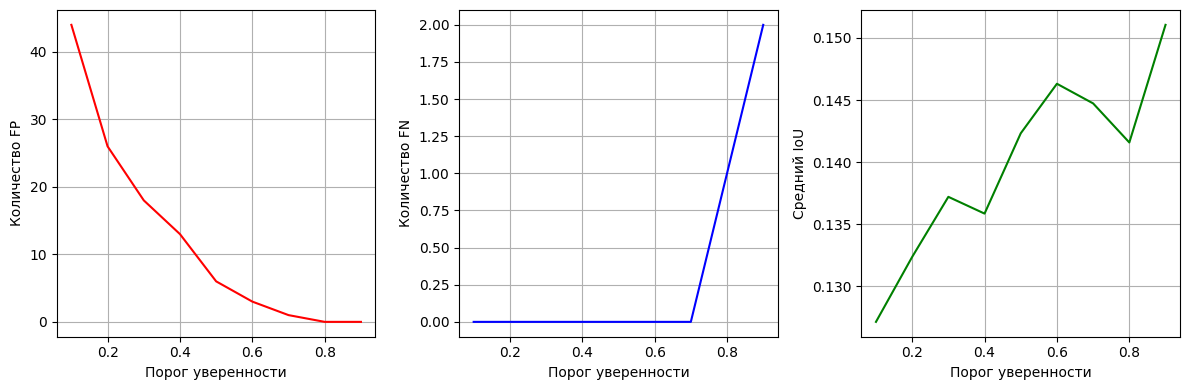

In [ ]:
# исследование оптимального порога уверенности
thresholds = np.linspace(0.1, 0.9, 9)
fp_results = []
fn_results = []
mean_ious = []

for threshold in thresholds:
    total_fp = 0
    total_fn = 0
    total_ious = []

    for idx, i in enumerate(image_indices):
        # загрузка данных
        image, target = voc_dataset[i]
        image_id = target['annotation']['filename'].split('.')[0]
        image_path = os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', f"{image_id}.jpg")
        xml_path = os.path.join('./data/VOCdevkit/VOC2007/Annotations', f"{image_id}.xml")

        # парсинг аннотации
        gt_boxes = parse_voc_annotation(xml_path)

        # трансформация
        img_pil = Image.open(os.path.join('./data/VOCdevkit/VOC2007/JPEGImages', os.path.basename(image_path))).convert("RGB")
        img_tensor = transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model(img_tensor)

        pred_boxes = outputs[0]['boxes'].cpu().numpy()
        pred_scores = outputs[0]['scores'].cpu().numpy()

        mask = pred_scores >= threshold
        pred_boxes = pred_boxes[mask]

        # расчет метрик
        fp = len(pred_boxes) - len(gt_boxes) if len(pred_boxes) > len(gt_boxes) else 0
        fn = len(gt_boxes) - len(pred_boxes) if len(gt_boxes) > len(pred_boxes) else 0

        total_fp += fp
        total_fn += fn

        # расчет IoU
        for gt_box in gt_boxes:
            for pred_box in pred_boxes:
                total_ious.append(calculate_iou(pred_box, gt_box))

    fp_results.append(total_fp)
    fn_results.append(total_fn)
    mean_ious.append(np.mean(total_ious) if total_ious else 0)

best_threshold_idx = np.argmax(mean_ious)
best_threshold = thresholds[best_threshold_idx]
print(f"Оптимальный порог уверенности: {best_threshold:.2f}")
print(f"При этом пороге:")
print(f"- Средний IoU: {mean_ious[best_threshold_idx]:.2f}")
print(f"- False Positive: {fp_results[best_threshold_idx]}")
print(f"- False Negative: {fn_results[best_threshold_idx]}")

# визуализация исследования
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(thresholds, fp_results, 'r-', label='False Positive')
plt.xlabel('Порог уверенности')
plt.ylabel('Количество FP')
plt.grid()

plt.subplot(1, 3, 2)
plt.plot(thresholds, fn_results, 'b-', label='False Negative')
plt.xlabel('Порог уверенности')
plt.ylabel('Количество FN')
plt.grid()

plt.subplot(1, 3, 3)
plt.plot(thresholds, mean_ious, 'g-', label='Средний IoU')
plt.xlabel('Порог уверенности')
plt.ylabel('Средний IoU')
plt.grid()

plt.tight_layout()
plt.show()

### Выводы и рекомендации
В ходе выполнения лабораторной работы производилась работа с Faster R-CNN и двухэтапным обнаружением объектов. Были визуализированы предсказания, проанализированы ошибки модели и проведены исследования по поиску баланса FN/FP. Также были сделаны следующие выводы:
1) Оптимальный порог уверенности зависит от требований задачи:
    - Для минимизации False Positive следует увеличить порог
    - Для минимизации False Negative следует уменьшить порог

2) Найденный компромиссный порог: 0.9

3) Для улучшения результатов можно:
    - Использовать аугментацию данных при обучении
    - Настроить гиперпараметры модели
    - Применить non-maximum suppression (NMS) для фильтрации пересекающихся bounding boxes
    - Рассмотреть использование более современных архитектур (например, EfficientDet)